In [158]:
# ML classes
from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager
from modelEvaluator import PerformanceValidator, ModelRunner

import pandas as pd
import numpy as np

from pathlib import Path
from itertools import product
import re

import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # for the line legend
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from matplotlib import colormaps
from matplotlib.colors import LinearSegmentedColormap
from sklearn.utils import resample

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, auc

import shap

In [159]:
def get_best_prediction_with_oligos_with_additional_features_with_run_plates(summary_df, pos=0, with_oligos=True,
                                                                             with_additional_features=False,
                                                                             with_run_plates=False, with_all=False):
    # If 'with_all' is True, return the best prediction across the entire DataFrame
    if with_all:
        return summary_df.reset_index().sort_values(by='auc', ascending=False).iloc[0, :]

    # Use all three levels when 'group_oligos' is False
    required_levels = ('with_oligos', 'with_additional_features', 'with_run_plates')
    feature_combination = (with_oligos, with_additional_features, with_run_plates)

    # Ensure the index contains the required level names
    if not all(level in summary_df.index.names for level in required_levels):
        raise ValueError(f"Index levels must include {required_levels}")

    # Attempt to retrieve the best prediction based on the specified combination
    try:
        # Access the specific subset of the DataFrame using .xs and sort by 'auc'
        best_prediction = (
            summary_df.xs(feature_combination, level=required_levels, drop_level=False)
            .reset_index()
            .sort_values(by='auc', ascending=False)
            .iloc[pos, :]
        )
    except KeyError:
        raise ValueError(f"No data available for combination: {feature_combination}")

    return best_prediction


def get_all_best_predictions_with_oligos_with_additional_features_with_run_plates(summary_df):
    best_predictions_dict = {}
    for with_oligos, with_additional_features, with_run_plates in product(config.with_oligos_options,
                                                                          config.with_additional_features_options,
                                                                          config.with_run_plates_options):
        if not (with_oligos or with_additional_features or with_run_plates):
            continue

        best_prediction = get_best_prediction_with_oligos_with_additional_features_with_run_plates(summary_df,
                                                                                                   with_oligos=with_oligos,
                                                                                                   with_additional_features=with_additional_features,
                                                                                                   with_run_plates=with_run_plates,
                                                                                                   with_all=False)

        label_parts = []
        if with_oligos:
            label_parts.append("with_oligos")
        if with_additional_features:
            label_parts.append("with_additional_features")
        if with_run_plates:
            label_parts.append("with_run_plates")
        key = "_".join(label_parts)  # Join the label parts with an underscore

        # Store the AUC statistics in the dictionary with the dynamic key
        best_predictions_dict[key] = best_prediction
    return best_predictions_dict


def calculate_mean_std_tpr(fpr_list, tpr_list, num_points=100):
    """
    Calculate mean FPR, mean TPR, and std TPR for ROC curves.

    Parameters:
        fpr_list (list of arrays): List of FPR values for each fold or bootstrap.
        tpr_list (list of arrays): List of TPR values for each fold or bootstrap.
        num_points (int): Number of points for mean_fpr (default: 100).
    
    Returns:
        mean_fpr (array): Common FPR grid.
        mean_tpr (array): Mean TPR values interpolated to mean_fpr.
        std_tpr (array): Standard deviation of TPR values at each mean_fpr point.
    """
    # Define the common FPR grid
    mean_fpr = np.linspace(0, 1, num_points)
    # Interpolate each TPR to the mean FPR grid
    #tpr_interpolated = [np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)]
    # Interpolate each TPR to the mean FPR grid
    tpr_interpolated = []
    for fpr, tpr in zip(fpr_list, tpr_list):
        # Ensure FPR and TPR start at (0.0, 0.0)
        if fpr[0] > 0.0:
            fpr = np.insert(fpr, 0, 0.0)
            tpr = np.insert(tpr, 0, 0.0)
        # Ensure FPR and TPR end at (1.0, 1.0)
        if fpr[-1] < 1.0:
            fpr = np.append(fpr, 1.0)
            tpr = np.append(tpr, 1.0)
        # Interpolate TPR to mean FPR grid
        tpr_interpolated.append(np.interp(mean_fpr, fpr, tpr))

    # Convert the list of interpolated TPRs to a NumPy array
    tpr_array = np.array(tpr_interpolated)

    # Calculate mean and standard deviation of TPR across folds
    mean_tpr = tpr_array.mean(axis=0)
    std_tpr = tpr_array.std(axis=0, ddof=1)  # Use ddof=1 for sample standard deviation

    mean_fpr = np.insert(mean_fpr, 0, 0.0)
    mean_tpr = np.insert(mean_tpr, 0, 0.0)
    std_tpr = np.insert(std_tpr, 0, 0.0)

    return mean_fpr, mean_tpr, std_tpr


def bootstrap_roc_ci(y_true, y_pred_proba, n_bootstraps=500):
    mean_fpr = np.linspace(0, 1, 100)
    bootstrapped_tprs = []
    aucs = []
    for i in range(n_bootstraps):
        y_resampled, y_pred_resampled = resample(y_true, y_pred_proba, stratify=y_true,
                                                 random_state=config.random_state + i)

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_resampled, y_pred_resampled)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # Ensure the curve starts at (0, 0)
        bootstrapped_tprs.append(interp_tpr)

        # Compute AUC
        aucs.append(auc(fpr, tpr))

    # Compute statistics
    bootstrapped_tprs = np.array(bootstrapped_tprs)
    mean_tpr = bootstrapped_tprs.mean(axis=0)
    std_tpr = bootstrapped_tprs.std(axis=0)
    mean_tpr[-1] = 1.0  # Ensure the curve ends at (1, 1)
    #Define the 95% CI bounds for TPR
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)  # Upper bound, capped at 1
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)  # Lower bound, floored at 0

    # Compute AUC statistics
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ci_lower = np.percentile(aucs, 2.5)
    ci_upper = np.percentile(aucs, 97.5)

    roc_metrics = {
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "tprs_upper": tprs_upper,
        "tprs_lower": tprs_lower,
        "auc_mean": mean_auc,
        "auc_std": std_auc,
        "auc_ci_lower": ci_lower,
        "auc_ci_upper": ci_upper
    }
    return roc_metrics


def calculate_bootstrap_roc_ci_from_fpr_tpr(fpr_list, tpr_list):
    """
    Calculate bootstrap-based ROC statistics (mean TPR, std TPR, confidence intervals)
    from precomputed FPR and TPR lists.

    Parameters:
        fpr_list (list of arrays): List of FPR values for each bootstrap iteration.
        tpr_list (list of arrays): List of TPR values for each bootstrap iteration.

    Returns:
        dict: Dictionary containing mean_fpr, mean_tpr, tprs_upper, tprs_lower, mean_auc, std_auc, auc_ci_lower, auc_ci_upper.
    """
    mean_fpr = np.linspace(0, 1, 100)
    bootstrapped_tprs = []
    aucs = []

    for fpr, tpr in zip(fpr_list, tpr_list):
        # Interpolate TPR to the mean FPR grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0  # Ensure the curve starts at (0, 0)
        bootstrapped_tprs.append(interp_tpr)

        # Compute AUC
        aucs.append(auc(fpr, tpr))

    # Convert to numpy array
    bootstrapped_tprs = np.array(bootstrapped_tprs)

    # Compute mean and std of TPR
    mean_tpr = bootstrapped_tprs.mean(axis=0)
    std_tpr = bootstrapped_tprs.std(axis=0)

    # Ensure the curve ends at (1, 1)
    mean_tpr[-1] = 1.0

    # Define the 95% CI bounds for TPR
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)  # Upper bound, capped at 1
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)  # Lower bound, floored at 0

    # Compute AUC statistics
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ci_lower = np.percentile(aucs, 2.5)
    ci_upper = np.percentile(aucs, 97.5)

    roc_metrics = {
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "tprs_upper": tprs_upper,
        "tprs_lower": tprs_lower,
        "auc_mean": mean_auc,
        "auc_std": std_auc,
        "auc_ci_lower": ci_lower,
        "auc_ci_upper": ci_upper
    }

    return roc_metrics


def plot_roc_curve_best_with_oligos_with_additional_features_with_run_plates(best_predictions_dict, with_oligos=True,
                                                                             with_additional_features=True,
                                                                             with_run_plates=True, figures_dir='./',
                                                                             ax=None, chance_color='red',
                                                                             suffix_label="", plot_title=None,
                                                                             save_fig=False, suffix_file=None):
    subgroup_name, subgroup_color = None, None
    if with_oligos and with_additional_features and with_run_plates:
        features_to_plot = 'with_oligos_with_additional_features_with_run_plates'
    elif with_oligos and with_additional_features:
        features_to_plot = 'with_oligos_with_additional_features'
    elif with_oligos and with_run_plates:
        features_to_plot = 'with_oligos_with_run_plates'
    elif with_oligos:
        features_to_plot = 'with_oligos'
    elif with_additional_features and with_run_plates:
        features_to_plot = 'with_additional_features_with_run_plates'
        subgroup_name = "Sex/Age + Run Plates"
        subgroup_color = config.additional_features_run_plates_only_color
    elif with_additional_features:
        features_to_plot = 'with_additional_features'
        subgroup_name = "Sex/Age"
        subgroup_color = config.additional_features_only_color
    elif with_run_plates:
        features_to_plot = 'with_run_plates'
        subgroup_name = "Run Plates"
        subgroup_color = config.run_plates_only_color
    else:
        return 0

    if ax is None:
        fig, ax = plt.subplots()

    if with_oligos:
        subgroup_name = best_predictions_dict[features_to_plot]['subgroup_name']
        subgroup_color = config.subgroups_colors[subgroup_name]

    ax = plot_roc_curve(best_predictions_dict[features_to_plot], subgroup_name + suffix_label, ax=ax,
                        subgroup_color=subgroup_color, chance_color=chance_color, plot_title=plot_title,
                        save_fig=save_fig, suffix_file=suffix_file, figures_dir=figures_dir)

    return ax


def plot_roc_curve(best_prediction, subgroup_name,
                   ax=None,
                   subgroup_color='dodgerblue',
                   chance_color='black',
                   alpha_ci=0.2, show_legend=True,
                   save_fig=False, set_type="",
                   suffix_file=None, figures_dir='./', sample_size=None,
                   plot_title=None):
    if ax is None:
        fig, ax = plt.subplots()

    roc_metrics = best_prediction['roc_metrics']
    ax.plot(roc_metrics['boot_mean_fpr'], roc_metrics['boot_mean_tpr'], color=subgroup_color, alpha=1.0,
            label=f"{subgroup_name} (AUC={round(roc_metrics['boot_auc_mean'], 3)} [{round(roc_metrics['boot_auc_ci_lower'], 2)}, {round(roc_metrics['boot_auc_ci_upper'], 2)}])",
            lw=3)
    ax.fill_between(roc_metrics['boot_mean_fpr'], roc_metrics['boot_tprs_lower'], roc_metrics['boot_tprs_upper'],
                    color="dodgerblue", alpha=alpha_ci, label='95% CI (Bootstrapping)')

    if set_type == "trainSet":
        ax.plot(roc_metrics['fpr'], roc_metrics['tpr'], color="black", alpha=1.0,
                label=r"Mean CV (AUC = %0.2f $\pm$ %0.2f)" % (roc_metrics['auc'], roc_metrics['auc_std']), lw=2)
        ax.fill_between(roc_metrics['fpr'], roc_metrics['tprs_lower'], roc_metrics['tprs_upper'], color='gray',
                        alpha=0.4, label=r"Folds Variability ($\pm$ 1 Std)")
    else:
        ax.plot(roc_metrics['fpr'], roc_metrics['tpr'], color="black", alpha=1.0,
                label=r"AUC = %0.2f " % (roc_metrics['auc']), lw=2)

    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color=chance_color, label='Random Classifier', alpha=.8)
    if show_legend:
        ax.legend(fontsize=7, loc="lower right")
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_xlabel('False Positive Rate', fontsize=9)

    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is not None:
        ax.set_title(plot_title, fontsize=10, weight='bold', pad=10)
    else:
        if sample_size is not None:
            plot_title = f"{best_prediction['estimator']}:{set_type} (N={sample_size})\nPrevalence threshold = {best_prediction['prevalence_threshold_min']}\n{best_prediction['num_oligos']} Peptides\n" + ' vs '.join(
                config.group_tests)
        else:
            plot_title = f"{best_prediction['estimator']}:{set_type}\nPrevalence threshold = {best_prediction['prevalence_threshold_min']}\n{best_prediction['num_oligos']} Peptides\n" + ' vs '.join(
                config.group_tests)
        ax.set_title(plot_title, fontsize=10, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=6, width=1.2)
    ax.tick_params(axis='y', colors='black', size=6, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)

    # Remove grid for a clean look
    ax.grid(False)

    # Set transparent background
    ax.patch.set_alpha(0.0)
    #ax.set_facecolor("white")

    if save_fig:
        if suffix_file is None:
            suffix_file = best_prediction['subgroup'] + "_" + set_type + "_" + best_prediction[
                'estimator'] + "_" + config.label_group_tests
        plt.savefig(Path(figures_dir) / f'roc_curve_best_{suffix_file}.png',
                    dpi=300, bbox_inches='tight')
    return ax


def best_auc_per_subgroup(summary_df, data_type='exist', with_additional_features=False, with_run_plates=False):
    best_auc_df = (
        summary_df.xs((data_type, with_additional_features, with_run_plates),
                      level=('data_type', 'with_additional_features', 'with_run_plates'),
                      drop_level=False)
        .reset_index()
        .sort_values(by='auc', ascending=False)
        .groupby('subgroup_name', sort=False)
        .first()
        .reindex(config.subgroups_order)  # Reindex to ensure all subgroups are represented in order
    )
    return best_auc_df


def best_auc_per_subgroup_with_additional_features_with_run_plates(summary_df, data_type='exist'):
    # Get best combinations with oligos only
    best_auc_df = best_auc_per_subgroup(summary_df, data_type,
                                        with_additional_features=False,
                                        with_run_plates=False)

    # Extract best configurations for each subgroup, conditionally including entropy/correlation based on options
    best_combinations = list(zip(
        best_auc_df.index,
        best_auc_df['prevalence_threshold_min'],
        best_auc_df['filter_by_correlation'],
        best_auc_df['filter_by_entropy']
    ))
    # Prepare to store results for each valid combination of with_additional_features and with_run_plates
    combined_results = []

    # Determine levels for indexing based on available options
    level_keys = ['data_type', 'with_oligos']
    if True in config.with_additional_features_options:  # Check if True is in options
        level_keys.append('with_additional_features')
    if True in config.with_run_plates_options:  # Check if True is in options
        level_keys.append('with_run_plates')

    # Create product of valid combinations
    for with_additional_features, with_run_plates in product(config.with_additional_features_options,
                                                             config.with_run_plates_options):
        # Prepare index values conditionally
        level_values = [data_type, True]
        if 'with_additional_features' in level_keys:
            level_values.append(with_additional_features)
        if 'with_run_plates' in level_keys:
            level_values.append(with_run_plates)

        # Filter the summary DataFrame to include only rows matching the current settings
        try:
            tmp = summary_df.xs(tuple(level_values), level=tuple(level_keys)).reset_index()
        except KeyError:
            continue  # Skip if the combination does not exist in the summary_df

        # Filter rows that match the best combinations for each subgroup
        tmp_filtered = tmp[
            tmp.apply(
                lambda row: (
                                row['subgroup_name'],
                                row['prevalence_threshold_min'],
                                row['filter_by_correlation'],
                                row['filter_by_entropy']
                            ) in best_combinations, axis=1
            )
        ]

        tmp_filtered = tmp_filtered.copy()
        tmp_filtered['with_oligos'] = True
        # Add columns for with_additional_features and with_run_plates only if they have both True and False options
        if True in config.with_additional_features_options:
            tmp_filtered['with_additional_features'] = with_additional_features
        if True in config.with_run_plates_options:
            tmp_filtered['with_run_plates'] = with_run_plates

        # Reorder based on SUBGROUPS_ORDER and add to the results list
        tmp_filtered = tmp_filtered.set_index('subgroup_name').reindex(config.subgroups_order)
        combined_results.append(tmp_filtered)

    # Concatenate results across all configurations
    final_df = pd.concat(combined_results, ignore_index=False)

    return final_df


def barplot_AUC_subgroups(auc_df, extra_auc_value=None, group_tests=None, ax=None, palette_colors=None,
                          extra_features_color="gray",
                          order_plot=None, save_fig=False, suffix_file=None, plot_title=None, set_type="",
                          figures_dir='./', sample_size=None):
    if ax is None:
        fig, ax = plt.subplots()
    if order_plot is None:
        order_plot = list(np.unique(auc_df.index))
    if palette_colors is None:
        palette_colors = sns.color_palette()[:len(order_plot)]

    sns.barplot(data=auc_df,
                x='subgroup_name', y='auc', hue='subgroup_name',
                errorbar=None, ax=ax, alpha=1.0, legend=False,
                palette=palette_colors, order=order_plot)
    cl = auc_df['roc_metrics'].apply(lambda x: x['boot_auc_ci_lower'] if isinstance(x, dict) else None)
    cu = auc_df['roc_metrics'].apply(lambda x: x['boot_auc_ci_upper'] if isinstance(x, dict) else None)
    auc_mean = auc_df['roc_metrics'].apply(lambda x: x['boot_auc_mean'] if isinstance(x, dict) else None)
    el = auc_mean - cl
    eu = cu - auc_mean

    #yerr = cu - cl
    params = {'x': order_plot, 'y': auc_df.loc[order_plot, 'auc'].values, 'yerr': [el, eu], 'fmt': 'none',
              'ecolor': 'black', 'capsize': 10}  #auc_df['std'],'fmt': 'none', 'ecolor': 'black', 'capsize': 10}
    ax.errorbar(**params)

    #Generate updated x-tick labels including prevalence_threshold_min and num_oligos
    formatted_labels = []
    for subgroup in order_plot:
        subgroup_data = auc_df[(auc_df.index == subgroup)]
        # Extract unique values of prevalence_threshold_min and num_oligos
        prevalence_values = subgroup_data['prevalence_threshold_min'].unique()
        num_oligos_values = subgroup_data['num_oligos'].unique()

        # Convert to integer and format as percentage
        prevalence_str = f"{round(prevalence_values[0])}%" if prevalence_values.size > 0 else "N/A"
        num_oligos_str = f"{round(num_oligos_values[0])}" if num_oligos_values.size > 0 else "N/A"

        # Construct the formatted label
        formatted_labels.append(f"{subgroup} ({prevalence_str}, {num_oligos_str} Peptides)")

    # Apply formatted x-tick labels
    ax.set_xticks(range(len(order_plot)))
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=7)

    #ax.set_xticks(ax.get_xticks())  # Set tick positions explicitly
    #ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0.1, 1.)
    ax.set_ylabel('AUC of predictions\nbased on Ig epitope repertoire', fontsize=8)
    #ax.set_xlabel("Subgroups of the antigen library", fontsize=8)
    ax.set_xlabel("")

    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{auc_df['estimator'].iloc[0]}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}"
        else:
            plot_title = f"{auc_df['estimator'].iloc[0]}:{set_type}\n{' vs '.join(group_tests)}"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    #ax.patch.set_alpha(0.0)
    ax.set_facecolor("white")

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)

    ax.axhline(0.5, color='red', linestyle='--', lw=2)

    if extra_auc_value is not None:
        #add second legend
        ax.axhline(y=extra_auc_value, color=extra_features_color, linestyle='--', linewidth=2, label='Sex/Age only')
        dotted_line = mlines.Line2D([], [], color=extra_features_color, linestyle='--', linewidth=2,
                                    label='Sex/Age only')
        # Add the second legend for the dotted line (wrap dotted_line in a list)
        ax.legend(handles=[dotted_line], framealpha=0.1, bbox_to_anchor=(1, 1.1), fontsize=6)

    if save_fig:
        if suffix_file is None:
            suffix_file = set_type + "_" + auc_df['estimator'].iloc[0] + "_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir, f'barplots_{suffix_file}.png'), dpi=300, bbox_inches='tight')
    return ax


def barplot_AUC_subgroups_comparison_with_dashed_lines(auc_df, extra_auc_value=None, group_tests=None, ax=None,
                                                       palette_colors=None,
                                                       extra_features_color='gray', order_plot=None, width=0.35,
                                                       set_type="", figures_dir='./', sample_size=None,
                                                       save_fig=False, suffix_file=None, plot_title=None):
    if ax is None:
        fig, ax = plt.subplots()
    if order_plot is None:
        order_plot = list(np.unique(auc_df.index))
    if palette_colors is None:
        base_palette = sns.color_palette()[:len(order_plot)]
        palette_colors = [mcolors.to_rgba(color, alpha=1.0) for color in base_palette]

    formatted_labels = []
    for i, subgroup in enumerate(order_plot):
        subgroup_data_false = auc_df[(auc_df.index == subgroup) & (auc_df['with_additional_features'] == False)]
        cl = subgroup_data_false['roc_metrics'].apply(lambda x: x['boot_auc_ci_lower'] if isinstance(x, dict) else None)
        cu = subgroup_data_false['roc_metrics'].apply(lambda x: x['boot_auc_ci_upper'] if isinstance(x, dict) else None)
        auc_mean = subgroup_data_false['roc_metrics'].apply(
            lambda x: x['boot_auc_mean'] if isinstance(x, dict) else None)
        el = auc_mean - cl
        eu = cu - auc_mean
        if not subgroup_data_false.empty:
            ax.bar(i - width / 2, subgroup_data_false['auc'].values[0], width=width,
                   color=palette_colors[i], label=f"{subgroup} (No Sex/Age)")
            # Add error bars
            ax.errorbar(i - width / 2, subgroup_data_false['auc'].values[0],
                        yerr=[el, eu],  #subgroup_data_false['std'].values[0], 
                        fmt='none', ecolor='black', capsize=10)

            prevalence_values = subgroup_data_false['prevalence_threshold_min'].unique()
            num_oligos_values = subgroup_data_false['num_oligos'].unique()

            # Convert values to proper format
            prevalence_str = f"{int(round(prevalence_values[0]))}%" if prevalence_values.size > 0 else "N/A"
            num_oligos_str = f"{int(round(num_oligos_values[0]))}" if num_oligos_values.size > 0 else "N/A"

            # Format x-axis label
            formatted_labels.append(f"{subgroup} ({prevalence_str}, {num_oligos_str} Peptides)")

        # Plot for 'with_bloodtests=True' using dashed lines (hatch)
        subgroup_data_true = auc_df[(auc_df.index == subgroup) & (auc_df['with_additional_features'] == True)]
        cl = subgroup_data_true['roc_metrics'].apply(lambda x: x['boot_auc_ci_lower'] if isinstance(x, dict) else None)
        cu = subgroup_data_true['roc_metrics'].apply(lambda x: x['boot_auc_ci_upper'] if isinstance(x, dict) else None)
        auc_mean = subgroup_data_true['roc_metrics'].apply(
            lambda x: x['boot_auc_mean'] if isinstance(x, dict) else None)
        el = auc_mean - cl
        eu = cu - auc_mean
        if not subgroup_data_true.empty:
            ax.bar(i + width / 2, subgroup_data_true['auc'].values[0], width=width,
                   color=palette_colors[i], edgecolor='black', hatch='//', label=f"{subgroup} (With Sex/Age)")
            # Add error bars
            ax.errorbar(i + width / 2, subgroup_data_true['auc'].values[0],
                        yerr=[el, eu],  #subgroup_data_true['std'].values[0], 
                        fmt='none', ecolor='black', capsize=10)

    # Customize the plot appearance
    ax.set_xticks(range(len(order_plot)))
    #ax.set_xticklabels(order_plot, rotation=45, ha='right', fontsize=7)  # Set fontsize=8 to reduce size
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=7)

    ax.set_ylim(0.1, 1.)
    ax.set_ylabel('AUC of predictions\nbased on Ig epitope repertoire', fontsize=8)
    ax.set_xlabel('')

    ax.axhline(0.5, color='red', linestyle='--', lw=2)

    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{auc_df['estimator'].iloc[0]}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}"
        else:
            plot_title = f"{auc_df['estimator'].iloc[0]}:{set_type}\n{' vs '.join(group_tests)}"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)

    # Custom legend for 'with additional features' using dashes instead of colors
    legend_elements = [Patch(facecolor='lightgray', edgecolor='black', hatch='////', label='True'),
                       Patch(facecolor='lightgray', edgecolor='black', label='False')]

    # Add the legend with a title
    legend = ax.legend(handles=legend_elements, title="with Sex/Age", loc='center', title_fontsize='7', fontsize=6,
                       framealpha=0.1, bbox_to_anchor=(0.85, 1.065))

    if extra_auc_value is not None:
        #add second legend
        ax.axhline(y=extra_auc_value, color=extra_features_color, linestyle='--', linewidth=2, label='Sex/Age')
        dotted_line = mlines.Line2D([], [], color=extra_features_color, linestyle='--', linewidth=2, label='Sex/Age')
        # Add the second legend for the dotted line (wrap dotted_line in a list)
        ax.legend(handles=[dotted_line], framealpha=0.1, bbox_to_anchor=(1, 1.12), fontsize=6)
        # Add the first legend back to the plot so that both legends are shown
        ax.add_artist(legend)

    if save_fig:
        if suffix_file is None:
            suffix_file = set_type + "_" + auc_df['estimator'].iloc[0] + "_" + "-".join(config.group_tests)
        plt.savefig(Path(figures_dir) / f'barplots_comparison_{suffix_file}.png', dpi=300, bbox_inches='tight')
    return ax


def plot_shap_values(values, features, ax=None, color_map='viridis', max_display=30,
                     group_tests=None, pattern=r'(bloodb|BloodB)', estimator_name="",
                     suffix_file=None, plot_title=None, set_type="", sample_size=None,
                     save_fig=False, figures_dir='./'):
    if group_tests is None:
        group_tests = ['group1', 'group2']
    if ax is None:
        fig, ax = plt.subplots()

    # SHAP summary plot without displaying
    shap.summary_plot(values, features=features, plot_type='dot', cmap=color_map,
                      max_display=max_display, plot_size=[5, 5], show=False)

    cbar = plt.gcf().axes[-1]  # Get the last axes, which corresponds to the color bar
    cbar.set_ylabel('Feature value', fontsize=10)  # Change the font size of the color bar label
    cbar.tick_params(labelsize=9)

    # Get current x-ticks and x-tick labels
    xticks = ax.get_xticks()
    #xticklabels = [f"{tick:.1f}" for tick in xticks]  # Format ticks to one decimal place
    # Set dynamic x-ticks and their labels
    ax.set_xticks(xticks)

    # Remove the default x-axis label "SHAP value"
    ax.set_xlabel('')  # Remove SHAP label

    # Manually add custom x-axis labels below the numeric ticks using transform=ax.transAxes for alignment
    ax.text(0.2, -0.06, group_tests[0], ha='center', va='top', fontsize=10, transform=ax.transAxes)
    ax.text(0.75, -0.06, group_tests[1], ha='center', va='top', fontsize=10, transform=ax.transAxes)

    # Add a centered label below the x-axis using the same transformation
    ax.text(0.5, -0.14, 'Prediction toward...', ha='center', va='top', fontsize=11, fontweight='bold',
            transform=ax.transAxes)

    # Set y-axis labels to avoid overlap (increase label spacing)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    yticklabels = [re.sub(pattern, '', label.get_text()) for label in ax.get_yticklabels()]
    ax.set_yticklabels(yticklabels, fontsize=8)
    # Move y-tick labels closer to the plot by adjusting labelpad
    ax.tick_params(axis='y', pad=-10)
    ax.yaxis.set_label_coords(-0.3, 0.5)
    ax.set_xlim([values.min(), values.max()])

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{estimator_name}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}"
        else:
            plot_title = f"{estimator_name}:{set_type}\n{' vs '.join(group_tests)}"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Draw horizontal grid lines
    for ytick in ax.get_yticks():
        ax.axhline(y=ytick, color='lightgrey', linestyle='--', linewidth=0.8)  # Adjust color and style as needed
    # Adjust layout and show the plot
    ax.grid(False)
    ax.patch.set_alpha(0.0)
    #ax.set_facecolor("white")

    if save_fig:
        if suffix_file is None:
            suffix_file = set_type + "_" + estimator_name + "_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir) / f'shap_plot_{suffix_file}.png', dpi=300, bbox_inches='tight')
    return ax


def get_top_features(feature_shap_values_df, group_tests=None, to_select_features=10):
    def truncate_description(text, max_length=90):
        # Check if text is None, and return None if it is
        if text is None:
            return None
        # If text is not None, proceed to truncate
        if len(text) > max_length:
            return text[:max_length] + '...'  # Truncate and add ellipsis
        return text

    top_features = feature_shap_values_df.iloc[0:to_select_features, [0, 2, 7, 8, 9, 1]]
    top_features[[group_tests[0], group_tests[1], 'Ratio (log10)']] = top_features[
        [group_tests[0], group_tests[1], 'Ratio (log10)']].round(2)
    top_features['Description'] = top_features['Description'].apply(lambda x: truncate_description(x))
    return top_features


# Function to create a color based on value (gradient) for percentages (same as in your code)
def colorize(val, min_val, max_val, palette='Reds'):
    norm_val = (val - min_val) / (max_val - min_val)  # Normalize value between 0 and 1
    if palette == 'Reds':
        color = colormaps['RdYlGn'](norm_val)  # Use the 'RdYlGn' color map for percentages
    else:
        color = colormaps['BuPu'](norm_val)  # Use the 'BuPu' color map
    return color


# Render the main table (same as your code)
def render_main_table(df, col_widths, row_height=0.625, font_size=11, header_color='lightgray',
                      row_colors=None, edge_color='w', bbox=None, ax=None, **kwargs):
    if bbox is None:
        bbox = [0, 0, 1, 1]
    if row_colors is None:
        row_colors = ['#f1f1f2', 'w']
    if ax is None:
        fig, ax = plt.subplots(figsize=(np.sum(col_widths), len(df) * row_height + 1))
        ax.axis('off')  # Turn off the axis

    # Get min/max values for scaling
    min_val = 0
    max_val = 100

    min_val_ratio = -2
    max_val_ratio = 2

    # Create table
    mpl_table = ax.table(cellText=df.values, bbox=bbox, colLabels=df.columns, cellLoc='center', colWidths=col_widths,
                         **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    # Iterate over each cell and apply color
    for (i, j), cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        cell.set_text_props(fontsize=7.5)  # Set a smaller font size for wrapped text

        if i == 0:  # Header
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor(header_color)
        else:

            # Apply color gradient to 'CFS', 'Ctrl', and 'Ratio (log)' columns
            if j == 2:  # 'CFS' column
                cell_val = df.iloc[i - 1, 2]
                color = colorize(cell_val, min_val, max_val, 'Reds')  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white

            elif j == 3:  # 'Ctrl' column
                cell_val = df.iloc[i - 1, 3]
                color = colorize(cell_val, min_val, max_val)  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white

            elif j == 4:  # 'Ratio (log)' column
                cell_val = df.iloc[i - 1, 4]
                color = colorize(cell_val, min_val_ratio, max_val_ratio, 'Blues')  # Get color based on value
                cell.set_facecolor(color)
                cell.set_text_props(color='black')  # Set text color to white

            else:
                # Alternate row colors for text columns
                cell.set_facecolor(row_colors[i % len(row_colors)])

    return ax


def render_header_main_table(ax=None):
    col_colors = ['lightgray', 'lightgray', 'lightgray']  # Color for the headers

    header_table = plt.table(cellLoc='center',
                             colWidths=[0.76, 0.292, 0.107], bbox=[0, 1, 1, 0.12],
                             cellColours=[col_colors])

    for (i, j), cell in header_table._cells.items():
        cell.set_edgecolor('w')
        if i == 0:  # Header
            cell.set_text_props(weight='bold', color='black')

    ax.text(0.34, 1.05, 'Peptide details', ha='center', color='black', weight='bold')
    ax.text(0.79, 1.035, 'Antibody responses\nappearing % in ...', ha='center', fontsize=10, color='black',
            weight='bold')
    ax.text(0.955, 1.035, 'Feature\nimportance', ha='center', fontsize=10, color='black', weight='bold')

    return ax


def plot_table_top_features(feature_shap_values_df, group_tests=None, ax=None, to_select_features=10, set_type="",
                            figure_dir='./', estimator_name='', suffix_file=None, save_fig=False):
    top_features_df = get_top_features(feature_shap_values_df, group_tests=group_tests,
                                       to_select_features=to_select_features)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

        # Render the header table first
    render_header_main_table(ax)

    # Ensure SHAP values are correctly formatted before rendering
    top_features_df['SHAP value'] = top_features_df['SHAP value'].round(2).astype(str)  # Ensure rounding is preserved

    # Render the main data table
    render_main_table(top_features_df, col_widths=[0.35, 2.15, 0.32, 0.32, 0.32, 0.35], ax=ax)

    # Hide the axes
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_frame_on(False)

    plt.tight_layout()
    if save_fig:
        if suffix_file is None:
            suffix_file = set_type + "_" + estimator_name + "_" + "-".join(group_tests)
        plt.savefig(Path(figure_dir) / f'table_top{to_select_features}_SHAPvalues_{suffix_file}.png', dpi=300,
                    bbox_inches='tight')
    return ax


def generate_feature_importance_table(values, colnames, oligos_metadata, features, estimator_name,
                                      group_test=None, figures_dir='./', set_type='',
                                      with_oligos=True, with_additional_features=False, with_run_plates=False):
    if group_test is None:
        return pd.DataFrame()

    feature_shap_values_df = pd.DataFrame({'SHAP value': np.abs(values).mean(0)}, index=colnames).sort_values(
        by='SHAP value', ascending=False)

    feature_shap_values_df = feature_shap_values_df.merge(oligos_metadata,
                                                          left_index=True, right_index=True, how='left').rename(
        columns={'full name': 'Protein name', 'len_seq': 'Protein length', 'pos': 'Start position',
                 'Organism_complete_name': 'Organism'})

    #filtered_index = feature_shap_values_df.index[~feature_shap_values_df.index.str.contains('bloodb', case=False)]
    keywords = ['agilent', 'corona2', 'twist', 'Sex', 'Age', 'run_plate']
    pattern = '|'.join(keywords)
    filtered_index = colnames[colnames.str.contains(pattern, case=False, regex=True)]

    percentiles = features[filtered_index].groupby(level=features.index.names[1]).mean()
    #print(percentiles)
    get_perc_columns = percentiles.columns[
        percentiles.columns.str.contains('agilent|corona2|twist|sex|run_plate', case=False)]
    percentiles[get_perc_columns] = percentiles[get_perc_columns].mul(100)
    percentiles = percentiles.T.rename(columns={0: f'{group_test[0]}', 1: f'{group_test[1]}'})

    feature_shap_values_df = pd.merge(feature_shap_values_df, percentiles, left_index=True, right_index=True,
                                      how='left')

    feature_shap_values_df['Ratio (log10)'] = np.log10(
        feature_shap_values_df[f'{group_test[1]}'] / feature_shap_values_df[f'{group_test[0]}'])

    feature_shap_values_df.reset_index(inplace=True)
    feature_shap_values_df.rename(columns={'index': 'Peptide ID'}, inplace=True)
    #feature_shap_values_df['Peptide ID'] = feature_shap_values_df['Peptide ID'].str.replace(r'^(agilent)_\s*', '', regex=True)

    # Define filename based on flags and save CSV
    filename = f"shap_values_{set_type}_{estimator_name}_{'-'.join(group_test)}" + (
        "_with_oligos" if with_oligos else "") + (
                   "_with_additional_features" if with_additional_features else "") + (
                   "_with_run_plates" if with_run_plates else "") + ".csv"

    feature_shap_values_df.to_csv(Path(figures_dir, filename), index=False)

    return feature_shap_values_df


def get_AUCs_permutation_test(features, target, best_auc, estimator_name, num_permutations=500, k=5):
    # Initialize the estimator
    estimator_kwargs = config.estimators_info[estimator_name]['estimator_kwargs']
    estimator = config.estimators_info[estimator_name]['estimator_class'](**estimator_kwargs)

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=config.random_state)

    # Permutation test
    permuted_aucs = []
    for _ in range(num_permutations):
        # Shuffle the target labels
        y_permuted = np.random.permutation(target)

        # K-fold CV
        permuted_probs = cross_val_predict(estimator, features, y_permuted, cv=cv, method='predict_proba', n_jobs=-1)[:,
                         1]

        # Perform LOOCV with permuted labels
        # permuted_probs = cross_val_predict(estimator, features, y_permuted, cv=LeaveOneOut(), method='predict_proba', n_jobs=-1)[:, 1]
        permuted_auc = roc_auc_score(y_permuted, permuted_probs)
        permuted_aucs.append(permuted_auc)

    # Calculate p-value
    p_value = np.sum(np.array(permuted_aucs) >= best_auc) / num_permutations

    return {"observed_auc": best_auc, "permuted_aucs": permuted_aucs, "p_value": p_value}


def plot_combined_histogram_density(original_auc, permuted_aucs, pvalue=None, group_tests=None, ax=None, set_type="",
                                    figures_dir="./", sample_size=None,
                                    estimator_name="", plot_title=None, suffix_file=None, save_fig=False):
    if ax is None:
        fig, ax = plt.subplots()  #figsize=(8, 6) 

    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('AUC Score', fontsize=10)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{estimator_name}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}\nDistribution of Permuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
        else:
            plot_title = f"{estimator_name}:{set_type}\n{' vs '.join(group_tests)}\nDistribution of Permuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    ax.axvline(original_auc, color='dodgerblue', linestyle='dashed', linewidth=2, label='Observed AUC')
    sns.histplot(permuted_aucs, bins=30, kde=True, color='gray', alpha=0.4, label='Permuted AUCs', ax=ax)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    if save_fig:
        if suffix_file is not None:
            suffix_file = set_type + estimator_name + "_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir) / f'Distribution_PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

    return ax


def plot_permuted_aucs_boxplot(original_auc, permuted_aucs, pvalue=None, group_tests=None, ax=None, set_type="",
                               figures_dir="./", sample_size=None,
                               estimator_name="", plot_title=None, suffix_file=None, save_fig=False):
    if ax is None:
        fig, ax = plt.subplots()  #figsize=(8, 6) 

    ax.set_ylabel('AUC Score', fontsize=10)
    #ax.set_xlabel('Permuted AUCs', fontsize=9) 
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # Add title to the plot
    if plot_title is None:
        if sample_size is not None:
            plot_title = f"{estimator_name}:{set_type} (N={sample_size})\n{' vs '.join(group_tests)}\nPermuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
        else:
            plot_title = f"{estimator_name}:{set_type}\n{' vs '.join(group_tests)}\nPermuted AUCs vs Observed AUC\nPermutation Test (p-value = {pvalue:.3f})"
    ax.set_title(plot_title, fontsize=12, weight='bold', pad=10)

    # Remove grid for a clean look
    ax.grid(False)
    ax.patch.set_alpha(0.0)

    # Add ticks on both x and y axes
    ax.tick_params(axis='x', colors='black', size=5, width=1.2)
    ax.tick_params(axis='y', colors='black', size=5, width=1.2)
    ax.xaxis.set_tick_params(which='both', top=False, bottom=True)
    ax.yaxis.set_tick_params(which='both', left=True, right=False)
    # Add border to the x and y axes (spines)
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.5)

    plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5),
                labels=['Permuted AUCs'])
    plt.xticks(fontsize=10)  # Adjust the font size as needed
    ax.set_ylim(0, 1)
    # Get the x position of the boxplot
    x_positions = [1]  # Since we have only one boxplot, its x-position is 1
    box_width = 0.1  # Adjust this value to change the width of the line
    xmin = x_positions[0] - box_width
    xmax = x_positions[0] + box_width
    ax.hlines(original_auc, xmin=xmin, xmax=xmax, color='dodgerblue', linestyle='dashed', linewidth=2,
              label='Observed AUC')
    #plt.axhline(original_auc, color='dodgerblue', linestyle='dashed', linewidth=2, label='Original AUC')

    ax.legend(fontsize=8)
    if save_fig:
        if suffix_file is not None:
            suffix_file = set_type + estimator_name + "_" + "-".join(group_tests)
        plt.savefig(Path(figures_dir) / f'Distribution_PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

    return ax

In [160]:
#var='orr'
#var='dcr'
#var='afp'
#var='cirrhosis'
#var='ecog'
#var='ehs'
var='mvi'

config_file=f"/home/creyna/Vogl-lab_Projects_git/HCC_MUW_analysis/Data/Metadata/config_file_v1_{var}.yaml"
config = Config(config_file)
config.filters_metadata =  {'Centre':'Vienna', 'group_test': 'HCC'}
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)

####################
#config.subgroups_colors.update({'Agilent library': config.subgroups_colors.pop('Aligent library')}) # if new name
####################

feature_manager = FeatureManager(config, metadata_handler, oligos_handler)
estimator_name = "XGBClassifier"
var_name = "-".join(config.group_tests)+"_all_model_summarized_predictions.joblib"
summary = joblib.load(Path(config.predictions_dir) / var_name)
summary = summary[estimator_name]
oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]

In [161]:
best_predictions = get_all_best_predictions_with_oligos_with_additional_features_with_run_plates(summary.predictions_train)
best_model = best_predictions['with_oligos'].to_dict()

best_features_names = summary.features_names_train[best_model['model_id']]
best_samples_train = summary.target_samples_train[best_model['model_id']]
best_shap_values_train = summary.shap_values_train[best_model['model_id']]
tmp = feature_manager.get_data_with_target()[best_features_names]
best_X_train, best_y_train = feature_manager.split_features_target_df(tmp[tmp.index.get_level_values('SampleName').isin(best_samples_train)])
best_data_train = best_X_train.join(best_y_train).set_index(config.col_target, append=True)

<Axes: title={'center': 'XGBClassifier:trainSet (N=46)\nPrevalence threshold = 50.0\n24 Peptides\nnon MVI vs MVI'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

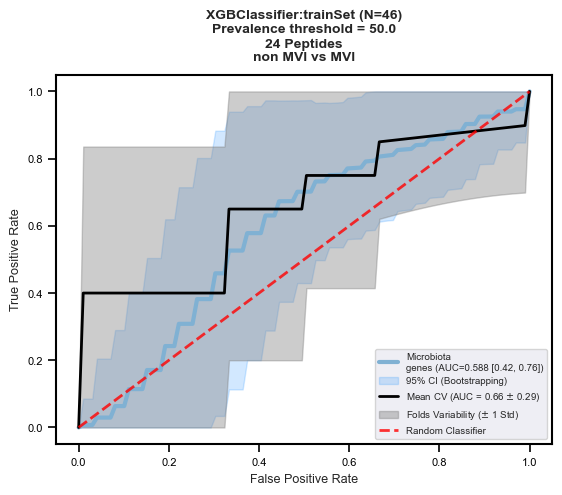

In [162]:
subgroup_name = best_model['subgroup_name']
subgroup_color = config.subgroups_colors[subgroup_name]
plot_roc_curve(best_model, subgroup_name, ax=None, subgroup_color=subgroup_color, chance_color='red', set_type = "trainSet",
               save_fig = True, figures_dir = config.figures_dir, sample_size=len(summary.target_samples_train[0])) 

/tmp/ipykernel_472120/2400842339.py:424: UserWarning: The palette list has more values (24) than needed (22), which may not be intended.
  sns.barplot(data=auc_df,
/home/creyna/miniconda3/envs/ML_env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


<Axes: title={'center': 'XGBClassifier:trainSet (N=46)\nnon MVI vs MVI'}, ylabel='AUC of predictions\nbased on Ig epitope repertoire'>

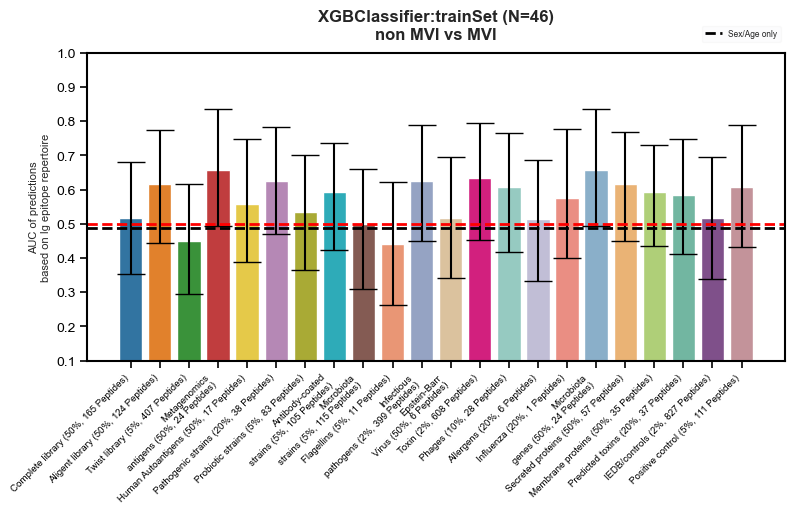

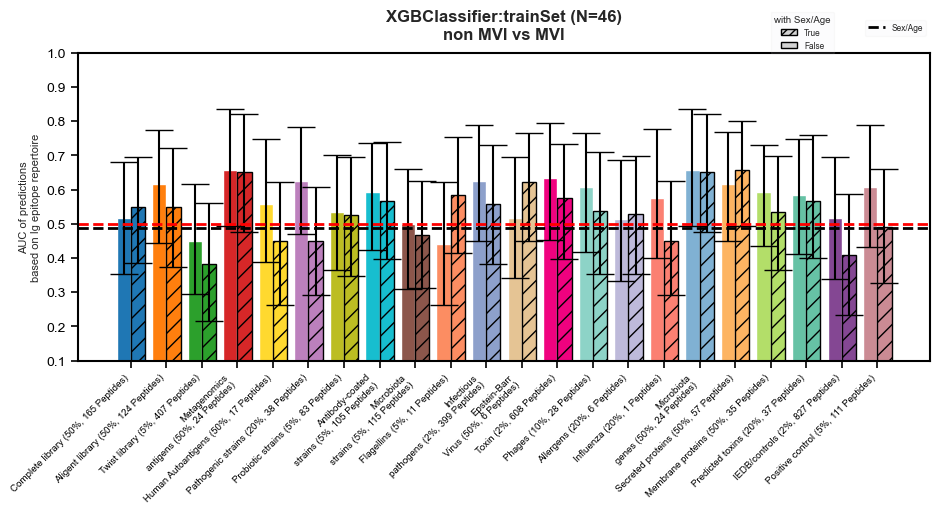

In [163]:
base_palette =  list(map(config.subgroups_colors.get, config.subgroups_order))

best_auc_train = best_auc_per_subgroup(summary.predictions_train, data_type = 'exist', with_additional_features = False, with_run_plates = False)
best_auc_train = best_auc_train.drop(index=["Negative control", "Random control"], errors="ignore")

sex_age_auc = best_predictions.get('with_additional_features', None)
if sex_age_auc is not None:
    sex_age_auc = sex_age_auc['auc']

fig, ax = plt.subplots(figsize=(9, 4))
barplot_AUC_subgroups(best_auc_train, extra_auc_value =sex_age_auc, group_tests = config.group_tests, ax=ax, palette_colors = base_palette, set_type="trainSet",  
                       sample_size=len(summary.target_samples_train[0]), figures_dir = config.figures_dir,
                      extra_features_color = config.additional_features_only_color, order_plot = config.subgroups_order[:-2], save_fig = True)


best_auc_comparison_train = best_auc_per_subgroup_with_additional_features_with_run_plates(summary.predictions_train)
best_auc_comparison_train = best_auc_comparison_train.drop(index=["Negative control", "Random control"], errors="ignore")
#best_auc_comparison_train = best_auc_comparison_train.dropna(subset=['subgroup'])

fig, ax = plt.subplots(figsize=(11, 4))
barplot_AUC_subgroups_comparison_with_dashed_lines(best_auc_comparison_train, extra_auc_value=sex_age_auc, group_tests = config.group_tests, ax=ax, palette_colors=base_palette,
                                                    sample_size=len(summary.target_samples_train[0]),
                                                   extra_features_color=config.additional_features_only_color, set_type="trainSet", figures_dir = config.figures_dir,
                                                   order_plot=config.subgroups_order[:-2], width=0.4, save_fig=True)

<Axes: >

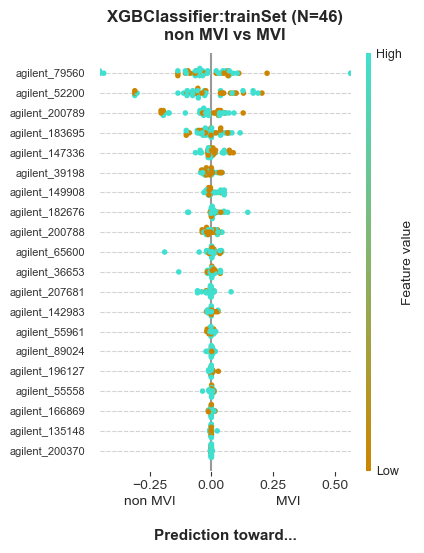

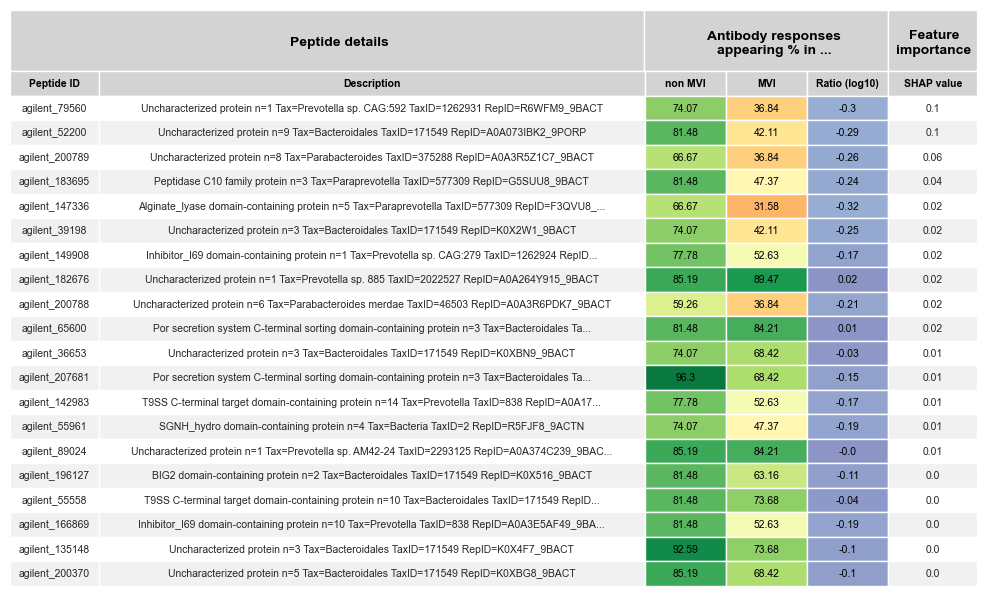

In [164]:
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494']) 
plot_shap_values(best_shap_values_train, best_X_train,
                 group_tests = config.group_tests, color_map=newCmap, max_display=20, estimator_name = best_model['estimator'], sample_size=len(summary.target_samples_train[0]),
                 figures_dir = config.figures_dir, save_fig = True, set_type='trainSet')

feature_importance_test = generate_feature_importance_table(best_shap_values_train, best_X_train.columns, oligos_metadata, best_data_train, best_model['estimator'],
                                      group_test = config.group_tests, figures_dir =config.figures_dir, set_type='trainSet',
                                      with_oligos = True, with_additional_features = False, with_run_plates=False)

plot_table_top_features(feature_importance_test, group_tests = config.group_tests, set_type='trainSet',
                          figure_dir = config.figures_dir, estimator_name =best_model['estimator'], save_fig = True, to_select_features=20)

/tmp/ipykernel_472120/2400842339.py:981: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5),


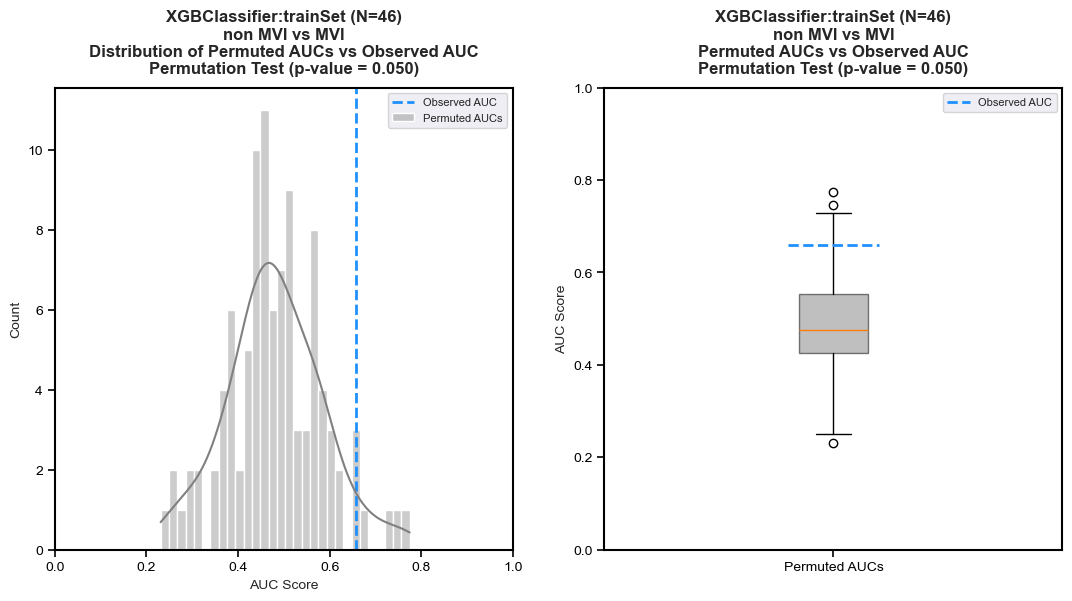

In [165]:
auc_permutation_train = get_AUCs_permutation_test(best_X_train, best_y_train, best_model['auc'], best_model['estimator'], num_permutations = 100, k = 5)
# Combine the two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_combined_histogram_density(original_auc=auc_permutation_train['observed_auc'], permuted_aucs=auc_permutation_train['permuted_aucs'],  sample_size=len(summary.target_samples_train[0]),
                                estimator_name=best_model['estimator'], set_type="trainSet", pvalue= auc_permutation_train['p_value'], group_tests = config.group_tests, ax=axes[0])
plot_permuted_aucs_boxplot(original_auc=auc_permutation_train['observed_auc'], permuted_aucs=auc_permutation_train['permuted_aucs'],  sample_size=len(summary.target_samples_train[0]),
                           estimator_name=best_model['estimator'], set_type="trainSet", pvalue= auc_permutation_train['p_value'], group_tests = config.group_tests, ax=axes[1])
suffix_file = "trainSet"+best_model['estimator']+"_" + "-".join(config.group_tests)
plt.savefig(Path(config.figures_dir)/ f'PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

## Complete Library

In [166]:
best_auc_train = best_auc_per_subgroup(summary.predictions_train, data_type = 'exist', with_additional_features = False, with_run_plates = False).reset_index()
completeLib_model =best_auc_train.iloc[0].to_dict()
completeLib_model['model_id'] = round(completeLib_model['model_id'])
completeLib_features_names = summary.features_names_train[completeLib_model['model_id']]
completeLib_samples_train = summary.target_samples_train[completeLib_model['model_id']]
completeLib_shap_values_train = summary.shap_values_train[completeLib_model['model_id']]
tmp = feature_manager.get_data_with_target()[completeLib_features_names]
completeLib_X_train, completeLib_y_train = feature_manager.split_features_target_df(tmp[tmp.index.get_level_values('SampleName').isin(completeLib_samples_train)])
completeLib_data_train = completeLib_X_train.join(completeLib_y_train).set_index(config.col_target, append=True)

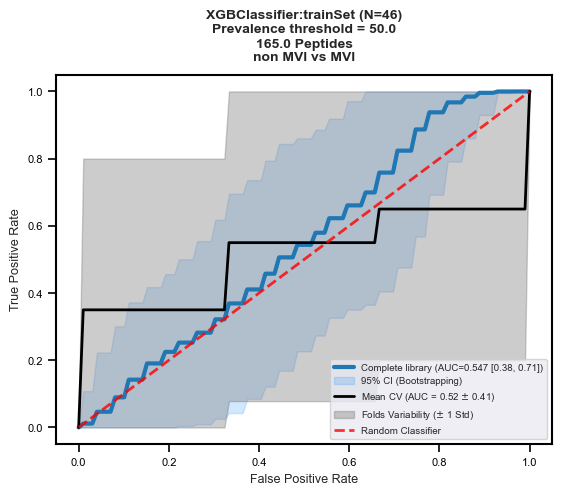

In [167]:
subgroup_name = completeLib_model['subgroup_name']
subgroup_color = config.subgroups_colors[subgroup_name]
plot_roc_curve(completeLib_model, subgroup_name, ax=None, subgroup_color=subgroup_color, chance_color='red', set_type = "trainSet", 
                sample_size=len(summary.target_samples_train[0]),
               save_fig = True, figures_dir = config.figures_dir) 
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494']) 

<Axes: >

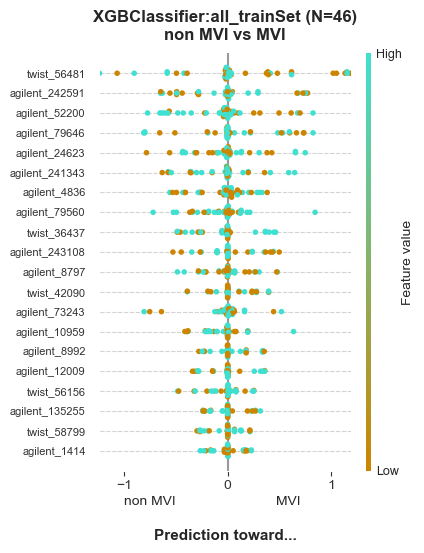

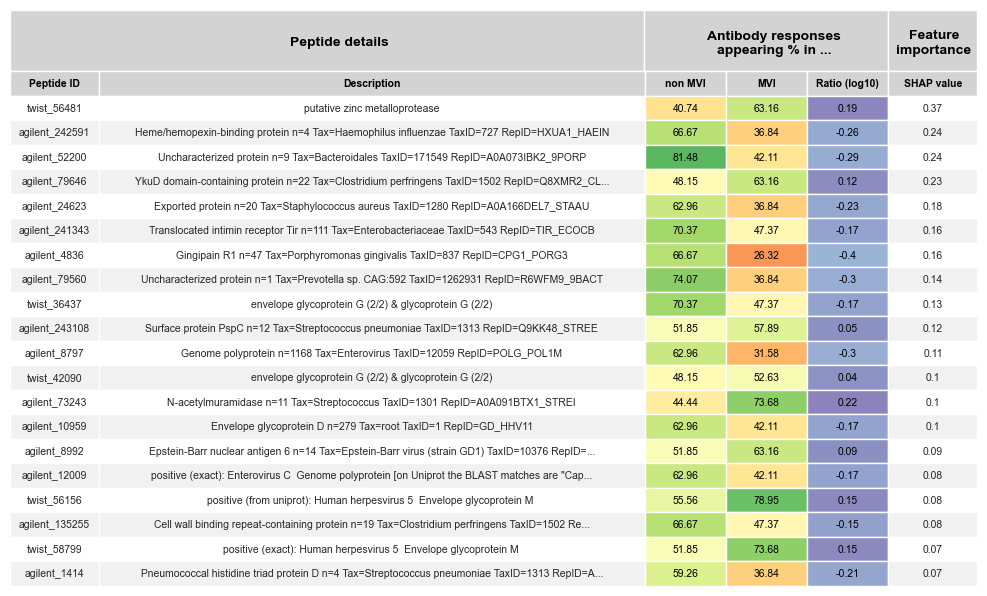

In [168]:
plot_shap_values(completeLib_shap_values_train, completeLib_X_train,
                 group_tests = config.group_tests, color_map=newCmap, max_display=20, estimator_name = completeLib_model['estimator'],
                 sample_size=len(summary.target_samples_train[0]),
                 figures_dir = config.figures_dir, save_fig = True, set_type='all_trainSet')

feature_importance_test = generate_feature_importance_table(completeLib_shap_values_train, completeLib_X_train.columns, oligos_metadata, completeLib_data_train, completeLib_model['estimator'],
                                      group_test = config.group_tests, figures_dir =config.figures_dir, set_type='all_trainSet',
                                      with_oligos = True, with_additional_features = False, with_run_plates=False)

plot_table_top_features(feature_importance_test, group_tests = config.group_tests, set_type='all_trainSet',
                          figure_dir = config.figures_dir, estimator_name =completeLib_model['estimator'], save_fig = True, to_select_features=20)

/tmp/ipykernel_472120/2400842339.py:981: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5),


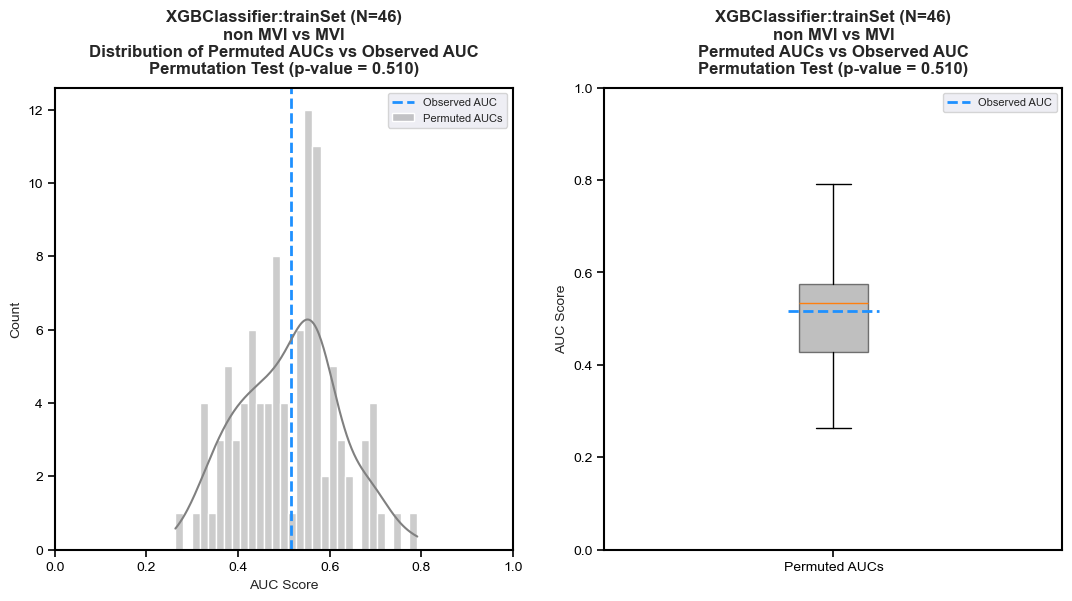

In [169]:
auc_permutation_train = get_AUCs_permutation_test(completeLib_X_train, completeLib_y_train, completeLib_model['auc'], completeLib_model['estimator'], num_permutations = 100, k = 5)
# Combine the two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_combined_histogram_density(original_auc=auc_permutation_train['observed_auc'], permuted_aucs=auc_permutation_train['permuted_aucs'], 
                                sample_size=len(summary.target_samples_train[0]),
                                estimator_name=completeLib_model['estimator'], set_type="trainSet", pvalue= auc_permutation_train['p_value'], group_tests = config.group_tests, ax=axes[0])
plot_permuted_aucs_boxplot(original_auc=auc_permutation_train['observed_auc'], permuted_aucs=auc_permutation_train['permuted_aucs'], sample_size=len(summary.target_samples_train[0]),
                           estimator_name=completeLib_model['estimator'], set_type="trainSet", pvalue= auc_permutation_train['p_value'], group_tests = config.group_tests, ax=axes[1])
suffix_file = "all_trainSet"+completeLib_model['estimator']+"_" + "-".join(config.group_tests)
plt.savefig(Path(config.figures_dir)/ f'PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

# External Set

In [170]:
config.filters_metadata =  {'Centre':'Hamburg', 'group_test': 'HCC'}

model_id = best_predictions['with_oligos']['model_id']
best_model_test = summary.predictions_ext.xs(model_id, level='model_id', drop_level=False).reset_index().iloc[0].to_dict()

best_features_names = summary.features_names_ext[best_model_test['model_id']]
best_samples_test = summary.target_samples_ext[best_model_test['model_id']]
best_shap_values_test = summary.shap_values_ext[best_model_test['model_id']]
tmp = feature_manager.get_data_with_target()[best_features_names]
best_X_test, best_y_test = feature_manager.split_features_target_df(tmp[tmp.index.get_level_values('SampleName').isin(best_samples_test)])
best_data_test = best_X_test.join(best_y_test).set_index(config.col_target, append=True)

<Axes: title={'center': 'XGBClassifier:extSet (N=31)\nPrevalence threshold = 50.0\n24 Peptides\nnon MVI vs MVI'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

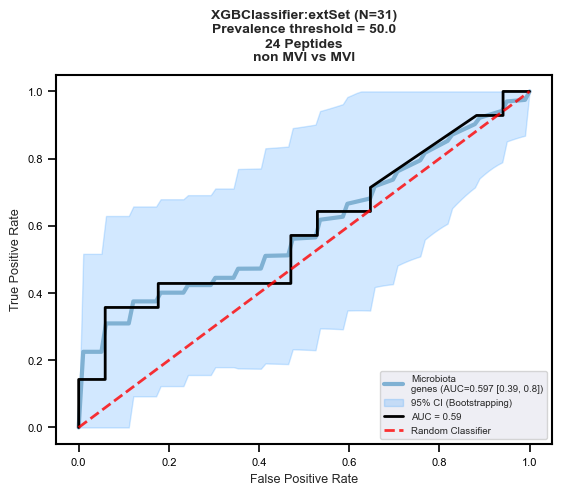

In [171]:
subgroup_name = best_model_test['subgroup_name']
subgroup_color = config.subgroups_colors[subgroup_name]
plot_roc_curve(best_model_test, subgroup_name, ax=None, subgroup_color=subgroup_color, chance_color='red', set_type = "extSet",
               sample_size=len(summary.target_samples_ext[0]),
               save_fig = True, figures_dir = config.figures_dir) 

/tmp/ipykernel_472120/2400842339.py:424: UserWarning: The palette list has more values (24) than needed (22), which may not be intended.
  sns.barplot(data=auc_df,
/home/creyna/miniconda3/envs/ML_env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


<Axes: title={'center': 'XGBClassifier:extSet (N=31)\nnon MVI vs MVI'}, ylabel='AUC of predictions\nbased on Ig epitope repertoire'>

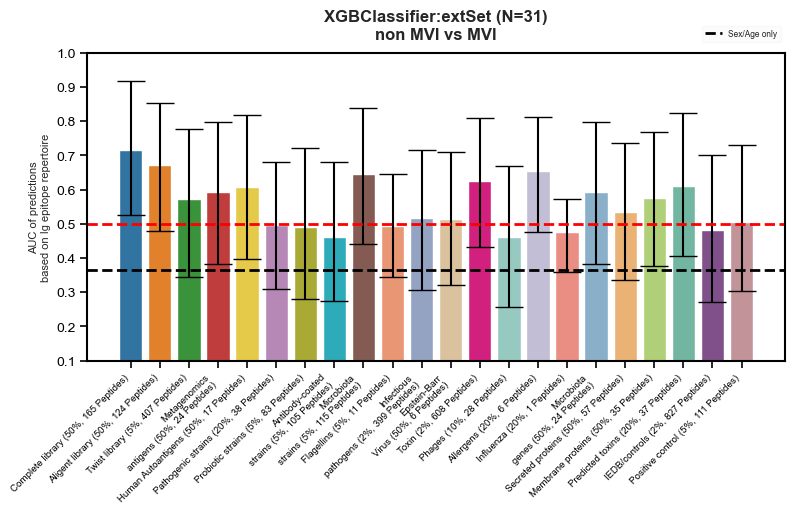

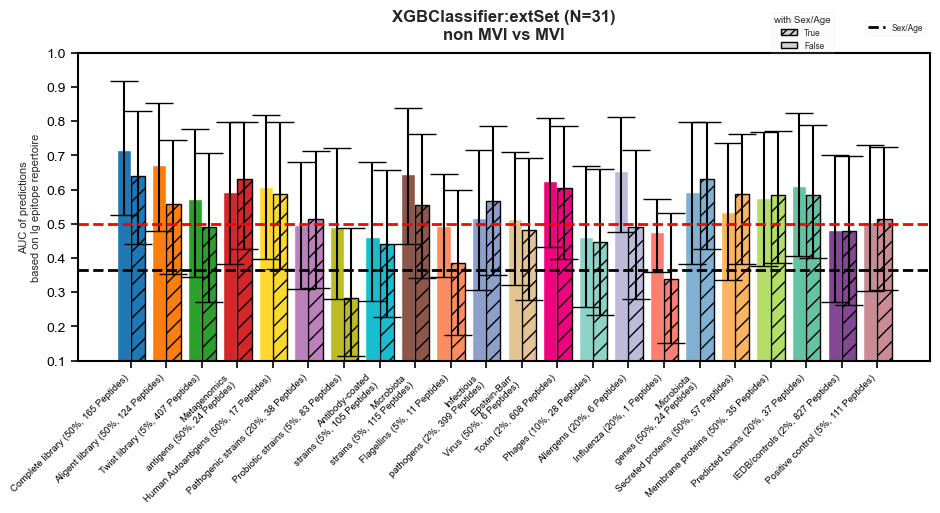

In [172]:
base_palette = list(map(config.subgroups_colors.get, config.subgroups_order))
best_auc_test = summary.predictions_ext[summary.predictions_ext.index.get_level_values('model_id').isin(best_auc_train['model_id'])].reset_index().set_index('subgroup_name')
best_auc_test = best_auc_test.drop(index=["Negative control", "Random control"], errors="ignore")

sex_age_auc = get_best_prediction_with_oligos_with_additional_features_with_run_plates(summary.predictions_ext,
                                                                                       with_oligos=False,
                                                                                       with_additional_features=True,
                                                                                       with_run_plates=False,
                                                                                       with_all=False)
if sex_age_auc is not None:
    sex_age_auc = sex_age_auc['auc']

fig, ax = plt.subplots(figsize=(9, 4))
barplot_AUC_subgroups(best_auc_test, extra_auc_value=sex_age_auc, group_tests=config.group_tests, ax=ax,
                      palette_colors=base_palette, set_type="extSet", figures_dir=config.figures_dir,
                      extra_features_color=config.additional_features_only_color,
                      sample_size=len(summary.target_samples_ext[0]),
                      order_plot=config.subgroups_order[:-2], save_fig=True)

best_auc_comparison_test = summary.predictions_ext[summary.predictions_ext.index.get_level_values('model_id').isin(
    best_auc_comparison_train['model_id'])].reset_index().set_index('subgroup_name')
best_auc_comparison_test = best_auc_comparison_test.drop(index=["Negative control", "Random control"], errors="ignore")

fig, ax = plt.subplots(figsize=(11, 4))
barplot_AUC_subgroups_comparison_with_dashed_lines(best_auc_comparison_test, extra_auc_value=sex_age_auc,
                                                   group_tests=config.group_tests, ax=ax, palette_colors=base_palette,
                                                   extra_features_color=config.additional_features_only_color,
                                                   set_type="extSet", figures_dir=config.figures_dir,
                                                   sample_size=len(summary.target_samples_ext[0]),
                                                   order_plot=config.subgroups_order[:-2], width=0.4, save_fig=True)

<Axes: >

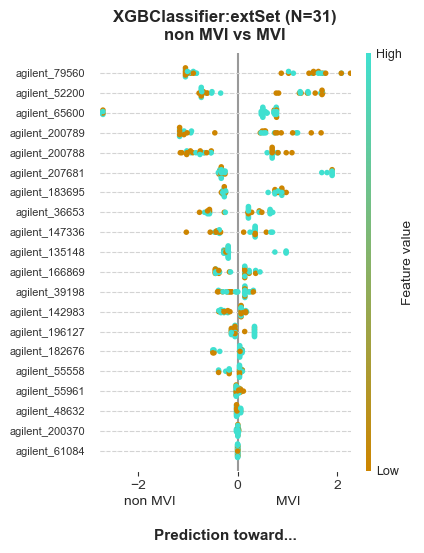

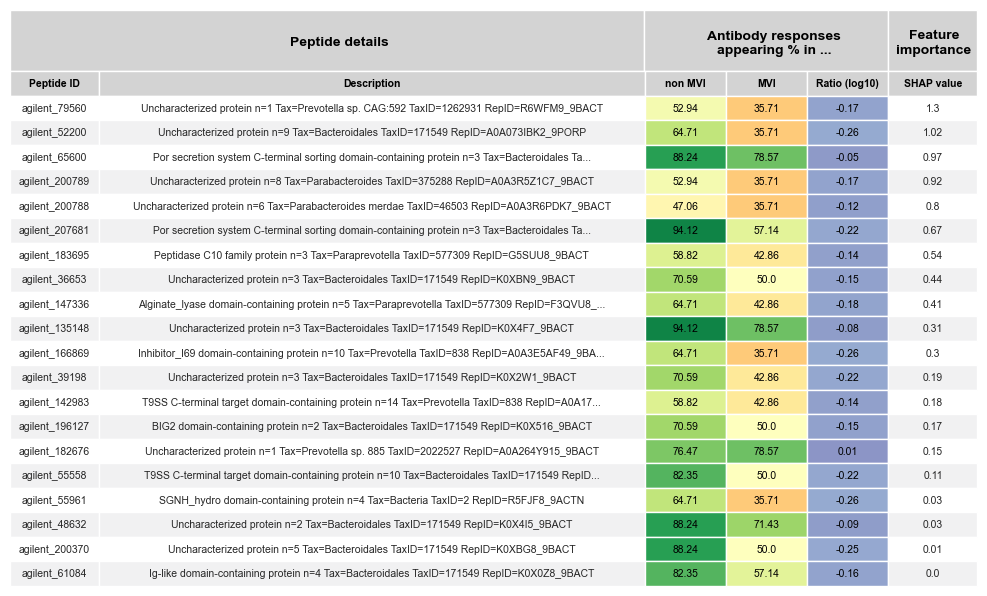

In [173]:
newCmap = LinearSegmentedColormap.from_list("", ['#CD8500',
                                                 '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494']) 
plot_shap_values(best_shap_values_test, best_X_test,
                 group_tests=config.group_tests, color_map=newCmap, max_display=20,
                 sample_size=len(summary.target_samples_ext[0]),
                 estimator_name=best_model_test['estimator'],
                 figures_dir=config.figures_dir, save_fig=True, set_type='extSet')

feature_importance_test = generate_feature_importance_table(best_shap_values_test, best_X_test.columns, oligos_metadata,
                                                            best_data_test, best_model_test['estimator'],
                                                            group_test=config.group_tests,
                                                            figures_dir=config.figures_dir, set_type='extSet',
                                                            with_oligos=True, with_additional_features=False,
                                                            with_run_plates=False)

plot_table_top_features(feature_importance_test, group_tests=config.group_tests, set_type='extSet',
                        figure_dir=config.figures_dir, estimator_name=best_model_test['estimator'], save_fig=True,
                        to_select_features=20)

/tmp/ipykernel_472120/2400842339.py:981: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5),


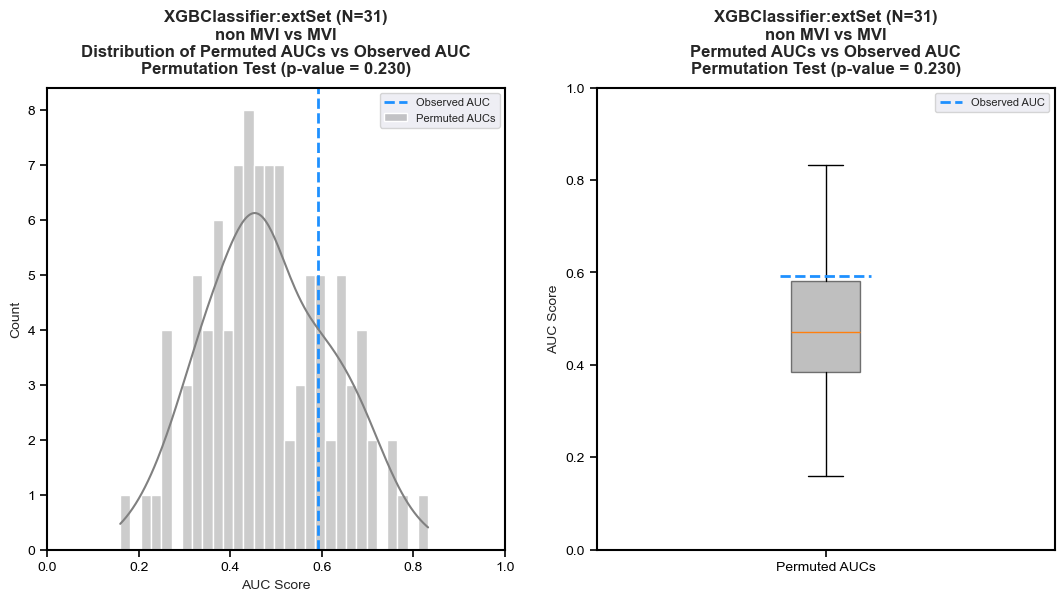

In [174]:
#improved later to use model from train set and then permute labels no cv
auc_permutation_test = get_AUCs_permutation_test(best_X_test, best_y_test, best_model_test['auc'], best_model_test['estimator'], num_permutations = 100, k=5)
# Combine the two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_combined_histogram_density(original_auc=auc_permutation_test['observed_auc'], permuted_aucs=auc_permutation_test['permuted_aucs'], sample_size=len(summary.target_samples_ext[0]),
                                estimator_name=best_model_test['estimator'], set_type="extSet", pvalue= auc_permutation_test['p_value'], group_tests = config.group_tests, ax=axes[0])
plot_permuted_aucs_boxplot(original_auc=auc_permutation_test['observed_auc'], permuted_aucs=auc_permutation_test['permuted_aucs'], sample_size=len(summary.target_samples_ext[0]),
                           estimator_name=best_model_test['estimator'], set_type="extSet", pvalue= auc_permutation_test['p_value'], group_tests = config.group_tests, ax=axes[1])
suffix_file = "extSet"+best_model_test['estimator']+"_" + "-".join(config.group_tests)
plt.savefig(Path(config.figures_dir)/ f'PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')

## Complete Library

In [175]:
best_auc_test = summary.predictions_ext[summary.predictions_ext.index.get_level_values('model_id').isin(best_auc_train['model_id'])].reset_index()
completeLib_model_test = best_auc_test.iloc[0].to_dict()
completeLib_model_test['model_id'] = round(completeLib_model_test['model_id'])
completeLib_features_names_test = summary.features_names_ext[completeLib_model_test['model_id']]
completeLib_samples_test = summary.target_samples_ext[completeLib_model_test['model_id']]
completeLib_shap_values_test = summary.shap_values_ext[completeLib_model_test['model_id']]
tmp = feature_manager.get_data_with_target()[completeLib_features_names_test]
completeLib_X_test, completeLib_y_test = feature_manager.split_features_target_df(tmp[tmp.index.get_level_values('SampleName').isin(completeLib_samples_test)])
completeLib_data_test = completeLib_X_test.join(completeLib_y_test).set_index(config.col_target, append=True)

<Axes: title={'center': 'XGBClassifier:extSet (N=31)\nPrevalence threshold = 50.0\n165 Peptides\nnon MVI vs MVI'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

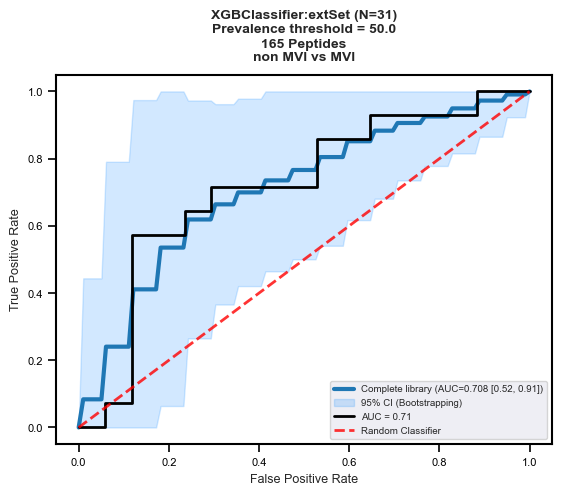

In [176]:
subgroup_name = completeLib_model_test['subgroup_name']
subgroup_color = config.subgroups_colors[subgroup_name]
plot_roc_curve(completeLib_model_test, subgroup_name, ax=None, subgroup_color=subgroup_color, chance_color='red', set_type = "extSet",
               sample_size=len(summary.target_samples_ext[0]),
               save_fig = True, figures_dir = config.figures_dir) 

<Axes: >

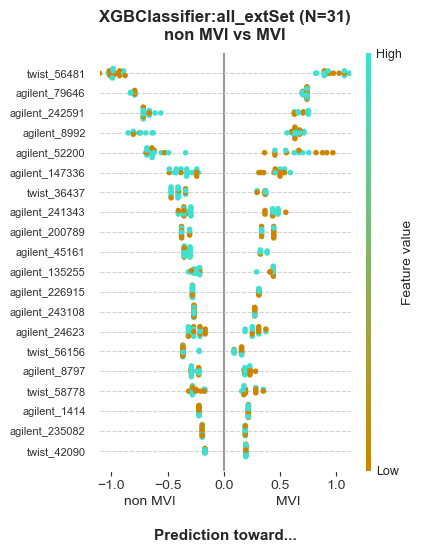

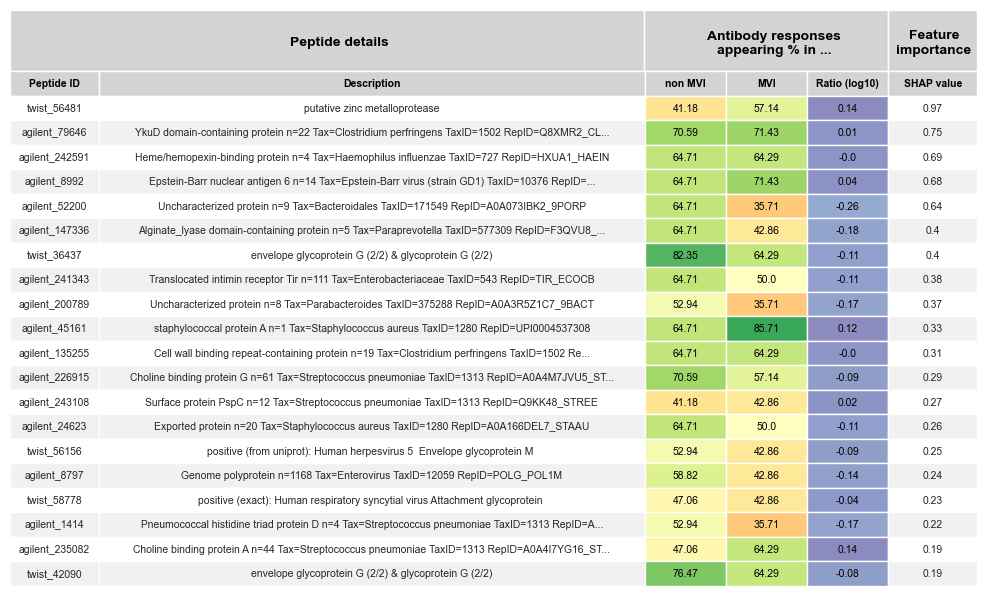

In [177]:
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])  # nonORR-ORR['#E78AC3', '#8DA0CB'])  # Controls - HCC ['#CD8500', '#40E0D0']) nonDCR -DCR ['#FFD92F','#E5C494']) 
plot_shap_values(completeLib_shap_values_test, completeLib_X_test,
                 group_tests = config.group_tests, color_map=newCmap, max_display=20, estimator_name = completeLib_model_test['estimator'], sample_size=len(summary.target_samples_ext[0]),
                 figures_dir = config.figures_dir, save_fig = True, set_type='all_extSet')

feature_importance_test = generate_feature_importance_table(completeLib_shap_values_test, completeLib_X_test.columns, oligos_metadata, completeLib_data_test, completeLib_model_test['estimator'],
                                      group_test = config.group_tests, figures_dir =config.figures_dir, set_type='all_extSet',
                                      with_oligos = True, with_additional_features = False, with_run_plates=False)

plot_table_top_features(feature_importance_test, group_tests = config.group_tests, set_type='all_extSet',
                          figure_dir = config.figures_dir, estimator_name =completeLib_model_test['estimator'], save_fig = True, to_select_features=20)

/tmp/ipykernel_472120/2400842339.py:981: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(permuted_aucs, vert=True, patch_artist=True, boxprops=dict(facecolor='gray', alpha=0.5),


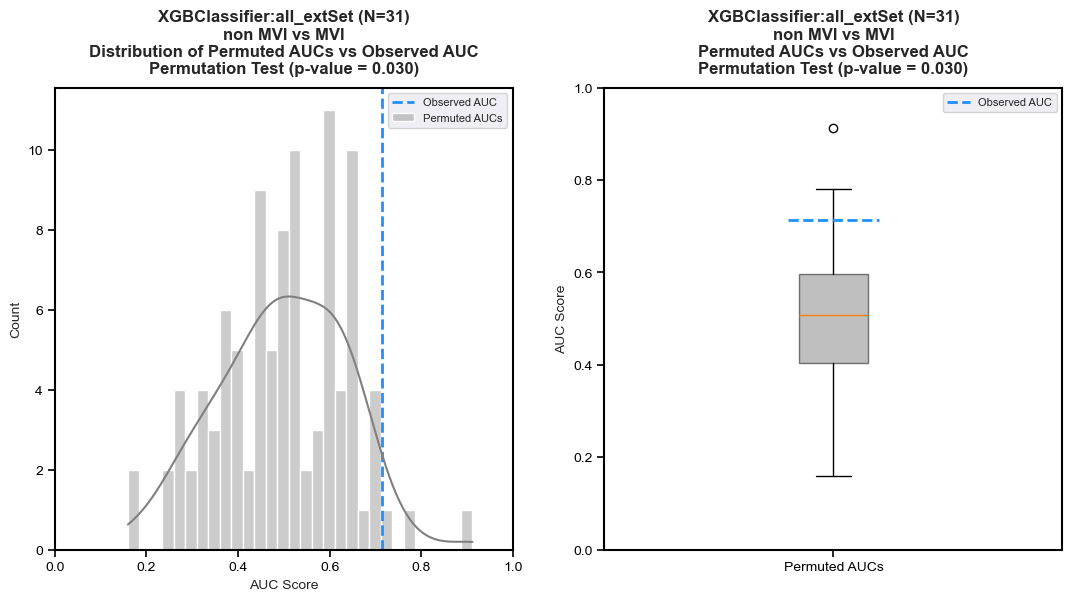

In [178]:
auc_permutation_test = get_AUCs_permutation_test(completeLib_X_test, completeLib_y_test, completeLib_model_test['auc'], completeLib_model_test['estimator'], num_permutations = 100, k=5)
# Combine the two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_combined_histogram_density(original_auc=auc_permutation_test['observed_auc'], permuted_aucs=auc_permutation_test['permuted_aucs'],  sample_size=len(summary.target_samples_ext[0]),
                                estimator_name=completeLib_model_test['estimator'], set_type="all_extSet", pvalue= auc_permutation_test['p_value'], group_tests = config.group_tests, ax=axes[0])
plot_permuted_aucs_boxplot(original_auc=auc_permutation_test['observed_auc'], permuted_aucs=auc_permutation_test['permuted_aucs'],  sample_size=len(summary.target_samples_ext[0]),
                           estimator_name=completeLib_model_test['estimator'], set_type="all_extSet", pvalue= auc_permutation_test['p_value'], group_tests = config.group_tests, ax=axes[1])
suffix_file = "all_exttSet"+completeLib_model_test['estimator']+"_" + "-".join(config.group_tests)
plt.savefig(Path(config.figures_dir)/ f'PermutationTest_{suffix_file}', dpi=300, bbox_inches='tight')